In [4]:
!pip install -Uq python-dotenv openai requests cohere langchain langchain-openai langgraph chromadb sentence-transformers kiwipiepy rank-bm25 transformers peft accelerate sentencepiece bitsandbytes dotenv


In [19]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
output_dir      = "../data/output_chunks"
chroma_dir      = "../data/chroma_db"
collection_name = "kosha_child_chunks"

# 경로 각자 맞춰서 지정 필요

In [9]:
import shutil
from pathlib import Path

chroma_dir = "/workspace/chroma_db"

if Path(chroma_dir).exists():
    shutil.rmtree(chroma_dir)

Path(chroma_dir).mkdir(parents=True, exist_ok=True)

chroma_client = chromadb.PersistentClient(path=chroma_dir)

In [10]:
import os, json
from pathlib import Path

from openai import OpenAI
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from dotenv import load_dotenv

load_dotenv()

# https://huggingface.co/jhgan/ko-sroberta-multitask 모델 링크
ko_ef = SentenceTransformerEmbeddingFunction(
    model_name="jhgan/ko-sroberta-multitask"
)

chroma_client = chromadb.PersistentClient(path=chroma_dir)
openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [11]:
existing_names = [c.name for c in chroma_client.list_collections()]
is_new = collection_name not in existing_names

collection = chroma_client.get_or_create_collection(
    name=collection_name,
    embedding_function=ko_ef,
    metadata={"hnsw:space": "cosine"}
)

if is_new:
    all_children = []
    for json_file in sorted(Path(output_dir).glob("*_child_chunks.json")):
        data = json.loads(json_file.read_text(encoding="utf-8"))
        all_children.extend(data["chunks"])

    print(f"자식 청크 총 {len(all_children)}개 로드")

    batch_size = 1000
    total = len(all_children)

    for i in range(0, total, batch_size):
        batch = all_children[i:i + batch_size]
        collection.add(
            ids       = [c["chunk_id"] for c in batch],
            # depth 정보 + 본문을 합쳐서 임베딩 (맥락 포함)
            documents = [
                f"{c['depth_1']} {c['depth_2']} {c['depth_3']} {c['content']}"
                for c in batch
            ],
            # 검색 결과와 함께 보여줄 데이터
            metadatas = [{
                "parent_id" : c.get("parent_id", ""),
                "source"    : c["source"],
                "title"     : c.get("title", ""),
                "year"      : str(c.get("year", "")),
                "status"    : c.get("status", "Active"),
                "category"  : c["category"],
                "task"      : c["task"],
                "space"     : c["space"],
                "depth_1"   : c["depth_1"],
                "depth_2"   : c["depth_2"],
                "depth_3"   : c["depth_3"],
            } for c in batch],
        )
        print(f"  {min(i + batch_size, total)}/{total} 저장", end="\r")

    print(f"\n\nChromaDB 저장 완료: {collection.count()}개 벡터")


자식 청크 총 11922개 로드
  11922/11922 저장

ChromaDB 저장 완료: 11922개 벡터


In [12]:
# chunk_id -> 부모 청크 전체 내용 
# 자식 청크로 검색한 뒤 `parent_id`를 이용해 부모 청크를 로드

parent_map = {}
for json_file in sorted(Path(output_dir).glob("*_parent_chunks.json")):
    data = json.loads(json_file.read_text(encoding="utf-8"))
    for c in data["chunks"]:
        parent_map[c["chunk_id"]] = c

print(f"부모 청크 {len(parent_map)}개 로드")

부모 청크 2109개 로드


In [13]:
corpus = []
for json_file in sorted(Path(output_dir).glob("*_child_chunks.json")):
    data = json.loads(json_file.read_text(encoding="utf-8"))
    corpus.extend(data["chunks"])

corpus1 = [c["content"] for c in corpus]

In [14]:
# child_map: 검색된 ID로 조각글(Content)과 부모ID를 찾음
# parent_map은 이미 셀 4에서 *_parent_chunks.json으로 올바르게 로드됨 → 재사용
child_map = {}

for c in corpus:
    c_id = c["chunk_id"]
    child_map[c_id] = {
        "content": c["content"],
        "parent_id": c["parent_id"]
    }

print(f"child_map: {len(child_map)}개, parent_map: {len(parent_map)}개")


child_map: 11922개, parent_map: 2109개


In [15]:
from kiwipiepy import Kiwi
from rank_bm25 import BM25Okapi

kiwi = Kiwi()

def kiwi_tokenize(text):
    return [token.form for token in kiwi.tokenize(text)]

tokenized_docs = [kiwi_tokenize(doc) for doc in corpus1]

bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)
    scores = bm25.get_scores(query_tokens)
    ranked_index = sorted(range(len(scores)), key=lambda i: scores[i],reverse=True)

    results = []
    for i in ranked_index[:top_k]:
        child = corpus[i]
        results.append({
            "chunk_id"  : child["chunk_id"],
            "parent_id" : child["parent_id"],
            "source"    : child["source"],
            "depth_1"   : child["depth_1"],
            "score"     : scores[i],
            "content"   : child["content"],
        })
    
    return results

In [16]:
# 랭킹의 역수를 취한 것을 더해서 
def rrf_rank(bm25_list, dense_list, k=60):
    candidate_scores = {}   
    for rank, doc in enumerate(bm25_list):
        candidate_scores[doc] = candidate_scores.get(doc, 0) + 1 / (k + rank)
    for rank, doc in enumerate(dense_list):
        candidate_scores[doc] = candidate_scores.get(doc, 0) + 1 / (k + rank)
    
    # 점수 높은 순으로 정렬하여 (ID, 점수) 리스트 반환
    ranked = sorted(candidate_scores.items(), key=lambda item: item[1], reverse=True)
    return ranked

In [20]:
from cohere import Client, TooManyRequestsError
import time

co = Client()

def cohere_rerank(query, rrf_candidate_ids, child_map, parent_map, max_retries=1, wait_seconds=10):
    # Reranker에게는 Parent 전체가 아닌, 검색된 Child의 핵심 내용만 전달 (정확도 향상)
    texts = [child_map.get(c_id, {}).get("content", "") for c_id in rrf_candidate_ids]

    def call_rerank_api():
        response = co.rerank(
            model='rerank-multilingual-v3.0',
            query=query,
            documents=texts,
            top_n=5 # 최종적으로 필요한 개수
        )
        
        unique_parents = []
        seen_parents = set()
        
        # Rerank 결과에서 Parent ID를 추출하고 중복 제거
        for r in response.results:
            child_id = rrf_candidate_ids[r.index]
            p_id = child_map.get(child_id, {}).get("parent_id", "")
            
            if p_id and p_id not in seen_parents:
                seen_parents.add(p_id)
                unique_parents.append(p_id)
        
        return unique_parents

    for attempt in range(max_retries + 1):
        try:
            return call_rerank_api()
        except TooManyRequestsError:
            if attempt < max_retries:
                print(f"재시도 중... ({attempt + 1}/{max_retries})")
                time.sleep(wait_seconds)
            else:
                raise

In [21]:
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool

checkpointer = MemorySaver()


In [22]:
import requests
import json
import os

@tool
def get_current_weather(city_name: str, units='metric'):
    '''
    OpenWeatherMap API를 사용하여 사용자가 지정한 도시의 날씨 정보를 가져오는 함수
    '''
    url = f'http://api.openweathermap.org/data/2.5/weather?q={city_name}&units={units}&appid={os.getenv("OPENWEATHER_API_KEY")}'
    response = requests.get(url)
    data = response.json()

    # API 오류 처리
    if "main" not in data:
        return json.dumps({
            "error": data.get("message", "날씨 정보를 가져올 수 없습니다."),
            "city": city_name
        }, ensure_ascii=False)

    weather_info = {
        "city"        : city_name,
        "temperature" : data["main"]["temp"],
        "feels_like"  : data["main"]["feels_like"],
        "humidity"    : data["main"]["humidity"],
        "description" : data["weather"][0]["description"],
        "wind_speed"  : data["wind"]["speed"],
    }

    return json.dumps(weather_info, ensure_ascii=False)

## Fine-tuning 모델 

 `yanolja/EEVE-Korean-Instruct-10.8B-v1.0` + `../final_adapter` 병합 모델


In [23]:
# 필요 시 1회 설치
# !pip install -Uq transformers peft accelerate bitsandbytes sentencepiece


In [24]:
from pathlib import Path
import re
import textwrap
import torch

from peft import PeftModel, PeftConfig
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

# ----------------------------
# 1) 앞단 은어 정규화 모델 (HF base + local adapter)
# ----------------------------
HF_BASE_MODEL = "yanolja/EEVE-Korean-Instruct-10.8B-v1.0"
ADAPTER_PATH = "../final_adapter"

# 실제 "병합"을 하려면 LOAD_IN_4BIT=False로 두는 쪽이 안전합니다.
# 메모리가 부족하면 LOAD_IN_4BIT=True + MERGE_AND_UNLOAD=False로 먼저 검증하세요.
MERGE_AND_UNLOAD = True
LOAD_IN_4BIT = False
SAVE_MERGED_MODEL = False
MERGED_MODEL_DIR = "../merged_normalizer_model"

if MERGE_AND_UNLOAD and LOAD_IN_4BIT:
    raise ValueError("MERGE_AND_UNLOAD=True 인 경우 LOAD_IN_4BIT=False를 권장합니다.")

# ----------------------------
# 2) 최종 답변 모델은 기존 그대로 유지
# ----------------------------
llm = init_chat_model("openai:gpt-4.1-mini")

def build_eeve_prompt(user_query: str) -> str:
    # EEVE 모델 카드의 Human / Assistant 템플릿을 그대로 사용
    instruction = textwrap.dedent(f"""
    너는 건설 현장 은어, 일본식 외래어, 현장 오타를 표준 건설 용어로 바꾸는 정규화 모델이다.

    규칙:
    1. 입력 문장의 의미는 유지하고 용어만 표준화한다.
    2. 지역명, 수량, 공종, 날씨, 행위는 보존한다.
    3. 설명하지 말고 변환된 문장 한 줄만 출력한다.
    4. 바꿀 은어가 없으면 원문 그대로 출력한다.

    입력: {user_query}
    출력:
    """).strip()

    return (
        "A chat between a curious user and an artificial intelligence assistant. "
        "The assistant gives helpful, detailed, and polite answers to the user's questions.\n"
        f"Human: {instruction}\n"
        "Assistant:"
    )

def load_term_normalizer(
    base_model_id: str = HF_BASE_MODEL,
    adapter_path: str = ADAPTER_PATH,
):
    adapter_path = Path(adapter_path)

    if not adapter_path.exists():
        raise FileNotFoundError(f"어댑터 경로를 찾을 수 없습니다: {adapter_path}")

    if not (adapter_path / "adapter_config.json").exists():
        raise FileNotFoundError(
            f"{adapter_path} 안에 adapter_config.json이 없습니다. "
            "PEFT save_pretrained() 결과 폴더인지 확인하세요."
        )

    peft_config = PeftConfig.from_pretrained(str(adapter_path))
    if getattr(peft_config, "base_model_name_or_path", None):
        print(f"[adapter base] {peft_config.base_model_name_or_path}")

    torch_dtype = (
        torch.bfloat16
        if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
        else torch.float16
    )

    quantization_config = None
    if LOAD_IN_4BIT:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch_dtype,
        )

    tokenizer = AutoTokenizer.from_pretrained(base_model_id, use_fast=False)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        torch_dtype=torch_dtype,
        device_map="auto",
        quantization_config=quantization_config,
    )

    model = PeftModel.from_pretrained(base_model, str(adapter_path))

    if MERGE_AND_UNLOAD:
        model = model.merge_and_unload()
        print("[info] base model + adapter 병합 완료")

        if SAVE_MERGED_MODEL:
            save_dir = Path(MERGED_MODEL_DIR)
            save_dir.mkdir(parents=True, exist_ok=True)
            model.save_pretrained(save_dir, safe_serialization=True)
            tokenizer.save_pretrained(save_dir)
            print(f"[info] 병합 모델 저장 완료: {save_dir}")

    model.eval()
    return tokenizer, model

normalizer_tokenizer, normalizer_model = load_term_normalizer()

@torch.inference_mode()
def normalize_query(query: str, max_new_tokens: int = 64) -> str:
    prompt = build_eeve_prompt(query)
    inputs = normalizer_tokenizer(prompt, return_tensors="pt")

    input_device = normalizer_model.get_input_embeddings().weight.device
    inputs = {k: v.to(input_device) for k, v in inputs.items()}

    output_ids = normalizer_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        eos_token_id=normalizer_tokenizer.eos_token_id,
        pad_token_id=normalizer_tokenizer.pad_token_id,
        use_cache=True,
    )

    gen_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    normalized = normalizer_tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    normalized = normalized.split("\n")[0].strip()
    normalized = re.sub(r"^(출력|정규화 결과|표준어)\s*:\s*", "", normalized)

    return normalized if normalized else query

@tool
def search_safety_regulation(query: str) -> str:
    """건설현장 안전 규정을 검색합니다. 안전 관련 질문이 들어오면 반드시 이 도구를 사용하세요."""

    # 0. 파인튜닝된 HF 모델로 은어 -> 표준어 정규화
    normalized_query = normalize_query(query)
    if normalized_query != query:
        print(f"[정규화] {query} -> {normalized_query}")

    # 1. BM25 + Dense
    bm25_top = [r["chunk_id"] for r in bm25_search(normalized_query, top_k=50)]
    dense_raw = collection.query(query_texts=[normalized_query], n_results=50)
    dense_top = dense_raw["ids"][0]

    # 2. RRF
    rrf_list = rrf_rank(bm25_top, dense_top)
    top_child_ids = [doc_id for doc_id, score in rrf_list[:40]]

    # 3. Rerank도 정규화된 질의로 수행
    reranked_parent_ids = cohere_rerank(normalized_query, top_child_ids, child_map, parent_map)

    # 4. context 구성
    context_chunks = []
    for parent_id in reranked_parent_ids:
        parent = parent_map.get(parent_id, {})
        content = parent.get("content", "")
        if content:
            source = parent.get("source", "")
            depth_1 = parent.get("depth_1", "")
            context_chunks.append(f"[출처: {source} / {depth_1}]\n{content}")

    return "\n\n".join(context_chunks) if context_chunks else "관련 내용을 찾을 수 없습니다."

tools = [search_safety_regulation, get_current_weather]
llm_with_tools = llm.bind_tools(tools)


[adapter base] yanolja/EEVE-Korean-Instruct-10.8B-v1.0


config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

[info] base model + adapter 병합 완료


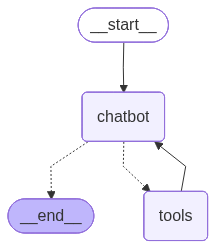

In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages

# State
class State(TypedDict):
    messages: Annotated[List, add_messages]

SYSTEM_PROMPT = """
[상황]
당신은 20년차 건설현장 안전 규정 전문가입니다.
당신은 50억 미만 중소규모 공사현장의 현장소장에게 안전에 관한 조언을 해주어야 합니다.
현장소장은 안전에 대해서 전문가가 아니기 때문에, 애매한 답변은 피하고, 명확하게 답변하세요.
또한 안전규정집에 근거하지 아니하고 답변을 할 경우, 공사 현장에 혼란을 줄 수 있으니,
안전 관련 질문은 반드시 search_safety_regulation 도구로 검색한 내용만을 참고해서 답변하세요.
search_safety_regulation 도구는 내부적으로 사용자 질문의 건설 은어/오타를 표준어로 정규화한 뒤 검색합니다.
질문에 날씨가 포함되는 경우에는 반드시 get_current_weather 도구로 최신 날씨 정보를 가져와서 답변에 반영하세요.

[도구 사용 규칙]
- 안전 규정 질문 -> search_safety_regulation 사용
- 날씨 질문 -> get_current_weather 사용
- 검색 결과가 없으면 없는 범위까지만 답하고, 추정하지 마세요.

[응답 규칙]
검색 결과에 없는 내용은 추론하지 말고 '해당 내용을 찾을 수 없습니다'라고 답하세요.
핵심적인 내용 위주로 간결하게 답변하세요.
항상 답변 마지막에 참조한 출처를 표시하세요.
"""

def chatbot(state: State):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

builder = StateGraph(State)
builder.add_node('chatbot', chatbot)
builder.add_node('tools', tool_node)

builder.add_edge(START, 'chatbot')
builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer=checkpointer)
graph


In [26]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str):
    try:
        result = graph.invoke(
            {"messages": [{"role": "user", "content": user_input}]},
            config=config
        )
        answer = result["messages"][-1].content
        print(answer)
        return answer

    except Exception as e:
        print(f"에러 발생: {e}")
        return None

def new_chat():
    config["configurable"]["thread_id"] = str(int(config["configurable"]["thread_id"]) + 1)
    print(f"새 대화를 시작합니다. thread_id={config['configurable']['thread_id']}")


In [28]:
print(chat("평택에서 공구리치려고 하는데 비가 너무 많이 오네, 작업해도 되나?"))

[정규화] 비 많이 올 때 거푸집 작업 안전 -> 비가 많이 올 때 거푸집 작업 안전에 유의해야 합니까?
평택에서 비가 많이 올 때 거푸집(공구리) 작업 관련 안전수칙은 다음과 같습니다.

- 시간당 3mm 이상의 비가 내릴 경우 콘크리트 타설 작업은 반드시 중지해야 합니다.
- 3mm 이하의 비가 내릴 때는 수분 유입 방지 조치를 하고, 책임기술자의 승인을 받은 경우에만 작업이 예외적으로 허용됩니다.
- 굴착면은 비가 올 경우 붕괴 우려가 있으므로 비닐 덮기, 측구 설치 등 빗물 침투 방지 조치를 해야 합니다.
- 집중호우 시에는 굴착사면 붕괴 방지, 침수에 따른 작업 중지, 근로자 출입 통제 등 안전 조치를 철저히 해야 합니다.
- 낙뢰가 발생하면 즉시 야외 작업을 중지하고 안전한 장소로 대피시켜야 합니다.

따라서, 현재 비가 많이 올 경우에는 작업을 중지하고, 적절한 방수 및 안전 대책을 마련한 후 작업을 진행해야 합니다.

참조: 
- D-C-15-2026 콘크리트(단순 슬래브 포함) 안전작업에 관한 기술지원규정
- D-C-11-2026 굴착 및 토공 안전작업에 관한 기술지원규정
- C-113-2020 취약시기 건설현장 안전작업지침
평택에서 비가 많이 올 때 거푸집(공구리) 작업 관련 안전수칙은 다음과 같습니다.

- 시간당 3mm 이상의 비가 내릴 경우 콘크리트 타설 작업은 반드시 중지해야 합니다.
- 3mm 이하의 비가 내릴 때는 수분 유입 방지 조치를 하고, 책임기술자의 승인을 받은 경우에만 작업이 예외적으로 허용됩니다.
- 굴착면은 비가 올 경우 붕괴 우려가 있으므로 비닐 덮기, 측구 설치 등 빗물 침투 방지 조치를 해야 합니다.
- 집중호우 시에는 굴착사면 붕괴 방지, 침수에 따른 작업 중지, 근로자 출입 통제 등 안전 조치를 철저히 해야 합니다.
- 낙뢰가 발생하면 즉시 야외 작업을 중지하고 안전한 장소로 대피시켜야 합니다.

따라서, 현재 비가 많이 올 경우에는 작업을 중지하고, 적절한 방수 및 안전 대책을 마련한 후 작업을 진행해야 합니

In [29]:
chat("서울에서 철근 공사를 좀 하려고 하는데, 이 정도 비면 해도 괜찮나?")

[정규화] 비 오는 날 철근 공사 작업 안전 -> 비가 오는 날 철근 공사 작업 안전에 대해 알려주시겠습니까?
서울에서 철근 공사를 비가 오는 상태에서 진행할 경우,
- 콘크리트 타설과 마찬가지로 시간당 3mm 이상의 비가 내릴 경우 작업을 중지해야 하며,
- 3mm 이하일 경우에는 수분 유입 방지 조치를 하여야 하고, 책임기술자의 승인을 받아야 작업이 가능합니다.
- 굴착 등 관련 작업도 빗물 침투를 막기 위해 비닐 덮기, 측구 설치 등의 조치를 하여야 하며,
- 집중호우, 낙뢰 등의 기상 위험 시 작업을 중지하고 근로자 안전을 최우선으로 확보해야 합니다.

비에 따른 철근 공사 구체적 작업 허용 여부는 현재 강우량과 현장 상황에 따라 달라지므로, 작업을 하기 전 반드시 강우량을 확인하고 안전조치를 철저히 하십시오.

참조: 
- D-C-15-2026 콘크리트(단순 슬래브 포함) 안전작업에 관한 기술지원규정
- D-C-11-2026 굴착 및 토공 안전작업에 관한 기술지원규정
- C-113-2020 취약시기 건설현장 안전작업지침


'서울에서 철근 공사를 비가 오는 상태에서 진행할 경우,\n- 콘크리트 타설과 마찬가지로 시간당 3mm 이상의 비가 내릴 경우 작업을 중지해야 하며,\n- 3mm 이하일 경우에는 수분 유입 방지 조치를 하여야 하고, 책임기술자의 승인을 받아야 작업이 가능합니다.\n- 굴착 등 관련 작업도 빗물 침투를 막기 위해 비닐 덮기, 측구 설치 등의 조치를 하여야 하며,\n- 집중호우, 낙뢰 등의 기상 위험 시 작업을 중지하고 근로자 안전을 최우선으로 확보해야 합니다.\n\n비에 따른 철근 공사 구체적 작업 허용 여부는 현재 강우량과 현장 상황에 따라 달라지므로, 작업을 하기 전 반드시 강우량을 확인하고 안전조치를 철저히 하십시오.\n\n참조: \n- D-C-15-2026 콘크리트(단순 슬래브 포함) 안전작업에 관한 기술지원규정\n- D-C-11-2026 굴착 및 토공 안전작업에 관한 기술지원규정\n- C-113-2020 취약시기 건설현장 안전작업지침'

In [30]:
test_jargon_queries = [
    "아시바 위에서 덴죠오 작업할 때 하이바 꼭 써야 합니까?",
    "공구리 타설 전에 와꾸 상태 확인해야 하나요?",
    "기리바리 설치할 때 도도메 작업은 어떻게 해야 합니까?",
    "아시바 해체할 때 바라시 순서랑 안전 규정이 어떻게 됩니까?",
    "겐바에서 렝가 쌓을 때 메지 두께 기준이 있습니까?",
    "하리 밑에서 공구리 타설할 때 세끼이다 고정 방법이 어떻게 됩니까?",
    "노보리 삼바시에서 덴죠오 작업 시 안전대 규정이 있습니까?",
    "도도메 설치하고 기리바리 받침 공구리 강도 기준이 어떻게 됩니까?",
    "하시라 세울 때 와꾸 고정하는 보도 규격이 있습니까?",
    "아시바 설치 후 겐바 안전점검은 얼마나 자주 해야 합니까?",
]

for query in test_jargon_queries:
    print(f"\n{'='*50}")
    print(f"질문: {query}")
    print(f"{'='*50}")
    chat(query)


질문: 아시바 위에서 덴죠오 작업할 때 하이바 꼭 써야 합니까?
[정규화] 아시바 덴죠오 작업 하이바 착용 -> 비계 천장 작업 시 안전모 착용을 해 주세요.
아시바 위에서 덴죠오(천장) 작업 시 개인 보호장구 착용에 관한 안전규정에 따르면 안전대(하이바) 착용은 필수입니다.

- 작업자는 작업발판이나 비계 위에서 추락 위험이 있으므로 안전대 등 개인 보호구를 반드시 착용해야 합니다.
- 작업구간 출입통제 및 작업 전 안전교육도 함께 실시되어야 하며, 추락방지용 안전난간, 추락방지망 등 추가 안전조치를 하여야 합니다.
- 특히 철근, 거푸집 작업 등에서도 안전대 착용이 강제됩니다.

따라서 아시바 위에서 덴죠오 작업을 할 때는 반드시 하이바(안전대)를 착용하여야 합니다.

참조:  
- D-C-15-2026 콘크리트(단순 슬래브 포함) 안전작업에 관한 기술지원규정  
- C-56-2017 리모델링 안전보건작업 기술지침

질문: 공구리 타설 전에 와꾸 상태 확인해야 하나요?
[정규화] 공구리 타설 전 와꾸 상태 확인 -> 콘크리트 타설 전에 테 상태를 확인해야 하나요?
네, 공구리(콘크리트 타설) 전에 와꾸 상태 확인은 반드시 해야 합니다.

- 콘크리트 타설 전에 거푸집 및 동바리의 변형, 변위, 지반 침하 유무 등을 점검하고 이상이 있을 경우 보수·보강해야 합니다.
- 데크플레이트 등 철골 구조부재의 경우도 콘크리트 타설 전 접합부 및 설치 상태를 꼼꼼히 확인해야 합니다.
- 작업 중에도 변형, 변위, 침하가 발생하지 않는지 감시자를 배치하여 계속 관찰해야 합니다.
- 이상 징후 발견 시 즉시 작업을 중지하고 근로자를 대피시키며, 안전을 확보한 후 작업을 재개해야 합니다.

따라서, 공구리 타설 전에 와꾸 상태 점검은 필수 안전조치입니다.

참조:
- D-C-15-2026 콘크리트(단순 슬래브 포함) 안전작업에 관한 기술지원규정
- D-C-3-2025 철골공사 안전작업에 관한 기술지원규정
- D-C-9-2026 거푸집 및 동바리 안전작업에 관한 기술지원규정

In [20]:
test_typo_queries = [
    "아시발 위에서 덴조 작업할 때 하이바 꼭 써야 합니까?",
    "공구리 타셜 전에 와꾸 상태 확인해야 하나요?",
    "기리바리 설치할 때 도도매 작업은 어떻게 해야 합니까?",
    "하리 밑에서 공구리 타설할 때 세끼이다 고정 방법이 어떻게 됩니까?",
    "아시바 설치 후 겐빠 안전점검은 얼마나 자주 해야 합니까?",
]

for i, query in enumerate(test_typo_queries):
    config["configurable"]["thread_id"] = str(i + 200)
    print(f"\n{'='*50}")
    print(f"질문: {query}")
    print(f"{'='*50}")
    chat(query)


질문: 아시발 위에서 덴조 작업할 때 하이바 꼭 써야 합니까?
[쿼리 재작성] 덴조 작업 시 하이바 착용 의무 → 덴조 작업 시 헬멧 착용 의무
덴조 작업 시 별도로 '하이바 착용'에 관한 직접적인 의무 조항은 안전규정 문서에서 찾을 수 없습니다. 다만, 작업 발판 위에서 높은 곳에서 작업할 경우에는 비계나 작업발판 설치가 필수이며, 추락 방지를 위해 안전대(하네스)를 포함한 개인보호구 착용이 요구됩니다. 따라서 덴조 작업 시 추락 위험이 있다면 안전모, 안전대 등 필수 개인 보호구를 반드시 착용해야 하며, 하이바는 추락 방지 안전대의 범주에 포함되는 것이 일반적입니다.

요약하면, 덴조 작업의 추락 위험이 있을 때는 작업 안전을 위해 반드시 안전대(하네스) 등 추락 방지 장비를 착용해야 하며, 하이바도 이에 포함될 수 있으므로 반드시 안전장비 착용 지침을 준수하시기 바랍니다.

참조: C-66-2016 내장공사의 안전보건작업 지침 (천장공사 안전관리사항)

질문: 공구리 타셜 전에 와꾸 상태 확인해야 하나요?
[쿼리 재작성] 공구리 타설 전 와꾸 상태 확인 여부 → 공구리 타설 전 틀 상태 확인 여부
공구리(거푸집 및 동바리) 타설 전에 반드시 와꾸 상태를 포함한 거푸집 및 동바리의 변형·변위, 침하 유무 등을 점검하고 이상이 있으면 보수·보강해야 합니다. 또한 콘크리트 타설 전 데크플레이트와 철골 보와의 접합부 시공상태, 데크플레이트 정렬상태와 연결상태를 확인하는 세밀한 사전검사를 실시해야 하며, 데크플레이트 양 끝 지지물은 견고하게 고정되어 있어야 합니다.

타설 중에는 거푸집 및 동바리의 변형, 변위가 발생하지 않도록 감시자를 배치하여 이상 발생 시 즉시 작업을 중지하고 근로자를 대피시키는 등 안전조치를 해야 합니다.

요약:  
- 콘크리트(공구리) 타설 전 와꾸 상태 점검 필수  
- 변형·변위 및 침하 유무 확인 후 이상 시 보수·보강  
- 데크플레이트 시공상태, 지지물 고정 상태 검사  
- 타설 중 지속 감시 및 이상 시 즉시 작업 중지 및